In [1]:
!pip install --upgrade torchao

import argparse, json, re, sys, warnings, pickle
from pathlib import Path
import numpy as np
import pandas as pd
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
warnings.filterwarnings('ignore')

PMAP   = {'Low':0,'Medium':1,'High':2,'Critical':3}
RPMAP  = {v:k for k,v in PMAP.items()}
BASE   = "microsoft/deberta-v3-small"
SEED   = 42

CRIT_KW = [
    r'\bphish\w*\b', r'\bfraud\w*\b', r'\bhack\w*\b', r'\bstolen\b',
    r'\bunauthori[sz]ed\b', r'\bdata\s+breach\b', r'\bransomware\b',
    r'\bmalware\b', r'\bidentity\s+theft\b', r'\bcompromised\b',
]
HIGH_KW = [
    r'\bcrash\w*\b', r'\bnot\s+(loading|working|responding|syncing)\b',
    r'\bcannot\s+(access|log)', r'\boutage\b', r'\blocke?d\s+out\b',
    r'\bpayment\s+fail\w*\b', r'\bdata\s+loss\b', r'\bbroken\b',
    r'\berror\b', r'\bdown\b', r'\bunable\s+to\b', r'\bcorrupt\w*\b',
]
LOW_KW   = [r'\bhow\s+do\s+i\b', r'\bwhere\s+is\b', r'\bheadquarters\b',
            r'\broadmap\b', r'\bfeature\s+request\b', r'\bhours\s+of\s+operation\b']
URG_KW   = [r'\bimmediately\b', r'\burgent\b', r'\basap\b', r'\bcritical\b']

CAT_W = {'Fraud':0.88,'Technical':0.52,'Account':0.38,'Billing':0.30,'General Inquiry':0.08}

def score_keyword(row):
    t = f"{row['Ticket_Subject']} {row['Ticket_Description']}".lower()
    s  = sum(0.32 for p in CRIT_KW if re.search(p, t))
    s += sum(0.20 for p in HIGH_KW if re.search(p, t))
    s -= sum(0.14 for p in LOW_KW  if re.search(p, t))
    s += sum(0.14 for p in URG_KW  if re.search(p, t))
    ts = float(np.clip(s / (abs(s) + 3.0 + 1e-9), 0, 1)) if s != 0 else 0.0
    return float(np.clip(0.60 * ts + 0.40 * CAT_W.get(row['Issue_Category'], 0.30), 0, 1))

def build_rt_medians(df):
    return (df.groupby(['Issue_Category','Priority_Level'])['Resolution_Time_Hours']
              .median().to_dict(),
            df.groupby('Priority_Level')['Resolution_Time_Hours'].median().to_dict())

def score_rt(row, grp_med, pri_med):
    actual   = float(row['Resolution_Time_Hours'])
    prio     = row['Priority_Level']
    prio_w   = PMAP[prio] / 3.0
    expected = grp_med.get((row['Issue_Category'], prio), pri_med.get(prio, 36.0))
    ratio    = actual / max(expected, 1.0)
    log_r    = float(np.log(max(ratio, 0.01)))
    if log_r > 0:
        sig = prio_w * float(np.tanh(log_r * 0.8))
    else:
        sig = (1 - prio_w) * float(np.tanh(-log_r * 0.5))
    return float(np.clip(sig, 0, 1))

SEV_TERMS = set(
    'cannot access locked stolen phishing fraud hacked unauthorized crash '
    'error fail broken outage down missing corrupted urgent data loss breach '
    'malware ransomware compromised account suspended payment charge suspicious '
    'unable sync attack security'.split()
)
ROUT_TERMS = set(
    'how where question general inquiry feature request roadmap headquarters '
    'information looking update plan curious wondering schedule'.split()
)
CAT_BASE = {'Fraud':0.82,'Technical':0.50,'Account':0.36,'Billing':0.30,'General Inquiry':0.10}

def score_lexical(row):
    words  = re.findall(r'\b\w+\b', f"{row['Ticket_Subject']} {row['Ticket_Description']}".lower())
    if not words: return 0.3
    total  = len(words)
    sev_h  = sum(1 for w in words if w in SEV_TERMS)  / total
    rout_h = sum(1 for w in words if w in ROUT_TERMS) / total
    lex    = float(np.clip(sev_h * 14.0 - rout_h * 7.0, 0, 1))
    sat    = (5 - int(row['Satisfaction_Score'])) / 4.0
    cat    = CAT_BASE.get(row['Issue_Category'], 0.28)
    return float(np.clip(0.45 * lex + 0.35 * sat + 0.20 * cat, 0, 1))

def score_semantic(df, out_dir):
    texts = (df['Ticket_Subject'].fillna('') + '. ' +
             df['Ticket_Description'].fillna('') +
             ' cat:' + df['Issue_Category'].fillna('') +
             ' ch:'  + df['Ticket_Channel'].fillna('')).tolist()
    try:
        from sentence_transformers import SentenceTransformer
        E = SentenceTransformer('all-MiniLM-L6-v2').encode(
            texts, batch_size=64, show_progress_bar=True, normalize_embeddings=True)
    except Exception:
        from sklearn.feature_extraction.text import TfidfVectorizer
        from sklearn.decomposition import TruncatedSVD
        from sklearn.preprocessing import normalize
        tv = TfidfVectorizer(max_features=6000, ngram_range=(1,2), sublinear_tf=True)
        E  = normalize(TruncatedSVD(100, random_state=SEED).fit_transform(tv.fit_transform(texts)))

    try:
        import umap
        E2 = umap.UMAP(n_components=8, n_neighbors=15, min_dist=0.05,
                       metric='cosine', random_state=SEED, verbose=False).fit_transform(E)
    except Exception:
        from sklearn.decomposition import PCA
        E2 = PCA(n_components=min(8, E.shape[1]-1), random_state=SEED).fit_transform(E)

    try:
        import hdbscan
        labels = hdbscan.HDBSCAN(min_cluster_size=30, min_samples=8,
                                  metric='euclidean').fit_predict(E2)
    except Exception:
        from sklearn.cluster import KMeans
        labels = KMeans(n_clusters=12, random_state=SEED, n_init=10).fit_predict(E2)

    df['_cid'] = labels
    cmap = {}
    for cid in set(labels):
        if cid == -1: continue
        cmap[cid] = df[df['_cid']==cid]['priority_ord'].mean()
    if cmap:
        lo, hi = min(cmap.values()), max(cmap.values())
        sig = [float(np.clip((cmap.get(c, lo)-lo)/(hi-lo+1e-9), 0, 1))
               if c != -1 else 0.5 for c in labels]
    else:
        sig = [0.5] * len(df)

    np.save(str(out_dir/'emb_reduced.npy'), E2)
    np.save(str(out_dir/'cluster_ids.npy'), labels)
    return np.array(sig)

def run_fusion(df, out_dir, mdl_dir):
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler
    from sklearn.model_selection import cross_val_score, StratifiedKFold
    from sklearn.metrics import cohen_kappa_score
    from scipy.stats import spearmanr

    SIGS  = ['sig_kw','sig_rt','sig_lex','sig_sem']
    NAMES = {'sig_kw':'NLP Keywords','sig_rt':'RT Mismatch',
             'sig_lex':'Lexical+Sat','sig_sem':'Semantic Cluster'}

    print("\nPairwise Cohen's κ:")
    for i, s1 in enumerate(SIGS):
        for s2 in SIGS[i+1:]:
            b1 = (df[s1]>=0.5).astype(int)
            b2 = (df[s2]>=0.5).astype(int)
            k  = cohen_kappa_score(b1, b2)
            a  = (b1==b2).mean()*100
            print(f"  {NAMES[s1][:16]:16s} x {NAMES[s2][:16]:16s}  κ={k:.3f}  agree={a:.1f}%")

    ablation = {}
    print("\nAblation:")
    for s in SIGS:
        rho, _ = spearmanr(df[s], df['priority_ord'])
        acc1   = ((df[s].apply(lambda x: 3 if x>=.75 else 2 if x>=.50 else 1 if x>=.25 else 0)
                   - df['priority_ord']).abs().le(1)).mean()
        print(f"  {NAMES[s]:20s}  rho={rho:.3f}  acc@1={acc1*100:.1f}%")
        ablation[NAMES[s]] = {'spearman_rho': round(rho,4), 'acc_within1': round(acc1,4)}

    X  = df[SIGS].values
    sc = StandardScaler()
    Xs = sc.fit_transform(X)
    y  = (df['priority_ord'] >= 2).astype(int).values

    lr = LogisticRegression(C=1.0, class_weight='balanced', max_iter=500, random_state=SEED)
    cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
    a  = cross_val_score(lr, Xs, y, cv=cv, scoring='accuracy')
    f  = cross_val_score(lr, Xs, y, cv=cv, scoring='f1_macro')
    print(f"\nFusion CV: acc={a.mean():.3f}±{a.std():.3f}  f1={f.mean():.3f}±{f.std():.3f}")

    lr.fit(Xs, y)
    df['sev_score'] = lr.predict_proba(Xs)[:, 1]

    wts = dict(zip(SIGS, np.abs(lr.coef_[0])))
    tot = sum(wts.values()) + 1e-9
    print("\nFusion weights:")
    for s, w in sorted(wts.items(), key=lambda x: -x[1]):
        pct = w/tot*100
        ablation[NAMES[s]]['fusion_weight_pct'] = round(pct,1)
        print(f"  {NAMES[s]:20s}: {pct:.1f}%")

    with open(out_dir/'ablation_table.json','w') as f_:
        json.dump(ablation, f_, indent=2)
    with open(mdl_dir/'fusion_model.pkl','wb') as f_:
        pickle.dump({'model':lr,'scaler':sc,'cols':SIGS}, f_)

    return df

def assign_labels(df):
    def to_sev(s):
        if s>=0.75: return 'Critical'
        if s>=0.50: return 'High'
        if s>=0.25: return 'Medium'
        return 'Low'

    df['inferred_sev'] = df['sev_score'].apply(to_sev)
    df['inferred_ord'] = df['inferred_sev'].map(PMAP)
    df['delta']        = df['inferred_ord'] - df['priority_ord']
    df['label']        = (df['delta'].abs() >= 2).astype(int)

    def mtype(r):
        if r['label'] == 0: return 'Consistent'
        return 'Hidden Crisis' if r['delta'] >= 2 else 'False Alarm'
    df['mtype'] = df.apply(mtype, axis=1)

    print(f"\nMismatch rate: {df['label'].mean()*100:.1f}%")
    print(df['mtype'].value_counts().to_string())
    return df

def stage1(csv_path, out_dir, mdl_dir):
    print("="*55 + "\nSTAGE 1 — Pseudo-label Generation\n" + "="*55)
    df = pd.read_csv(csv_path)
    df['priority_ord'] = df['Priority_Level'].map(PMAP)
    print(f"Loaded {len(df):,} tickets")

    print("Signal 1: keyword NLP...")
    df['sig_kw']  = df.apply(score_keyword, axis=1)

    print("Signal 2: RT mismatch...")
    gm, pm        = build_rt_medians(df)
    df['sig_rt']  = df.apply(lambda r: score_rt(r, gm, pm), axis=1)

    print("Signal 3: lexical + satisfaction...")
    df['sig_lex'] = df.apply(score_lexical, axis=1)

    print("Signal 4: semantic clustering...")
    df['sig_sem'] = score_semantic(df, out_dir)

    df = run_fusion(df, out_dir, mdl_dir)
    df = assign_labels(df)

    out = out_dir / 'labeled_tickets.csv'
    df.to_csv(out, index=False)
    print(f"\nSaved: {out}")
    return df


def rt_tier(h):
    if h <= 10: return 'FAST'
    if h <= 45: return 'MID'
    return 'SLOW'

def make_input(row):
    rt = float(row.get('Resolution_Time_Hours', 30))
    return (f"[SUBJ] {row['Ticket_Subject']} "
            f"[BODY] {row['Ticket_Description']} "
            f"| cat:{row['Issue_Category']} "
            f"| ch:{row['Ticket_Channel']} "
            f"| rt:{rt_tier(rt)} "
            f"| pri:{row['Priority_Level']}")

class TicketDS(Dataset):
    def __init__(self, texts, labels, tok):
        self.enc = tok(list(texts), truncation=True, padding='max_length',
                       max_length=256, return_tensors='pt')
        self.y   = torch.tensor(labels, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i):
        return {k: v[i] for k, v in self.enc.items()} | {'labels': self.y[i]}

def run_eval(model, loader, device, thr=0.5):
    from sklearn.metrics import accuracy_score, f1_score
    model.eval()
    probs, ys = [], []
    with torch.no_grad():
        for b in loader:
            ids = b['input_ids'].to(device)
            msk = b['attention_mask'].to(device)
            out = model(input_ids=ids, attention_mask=msk)
            probs += torch.softmax(out.logits.float(), -1)[:,1].cpu().tolist()
            ys    += b['labels'].tolist()
    probs = np.array(probs); ys = np.array(ys)
    preds = (probs >= thr).astype(int)
    acc   = accuracy_score(ys, preds)
    f1    = f1_score(ys, preds, average='macro', zero_division=0)
    f1c   = f1_score(ys, preds, average=None,   zero_division=0)
    return acc, f1, f1c, probs, ys

def stage2(df, mdl_dir, epochs, batch_size):
    from sklearn.model_selection import train_test_split
    from sklearn.utils import resample
    from sklearn.metrics import classification_report, confusion_matrix
    from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_cosine_schedule_with_warmup
    from peft import LoraConfig, get_peft_model, TaskType, PeftModel

    print("\n" + "="*55 + "\nSTAGE 2 — DeBERTa-v3-small + LoRA\n" + "="*55)
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Device: {device}" + (f" | {torch.cuda.get_device_name(0)}" if device=='cuda' else ''))

    for c in ['Ticket_Subject','Ticket_Description','Issue_Category','Ticket_Channel','Priority_Level']:
        df[c] = df[c].astype(str)

    df['input_text'] = df.apply(make_input, axis=1)
    X = df['input_text'].values
    y = df['label'].values.astype(int)

    X_tv, X_te, y_tv, y_te = train_test_split(X, y, test_size=0.10, stratify=y, random_state=SEED)
    X_tr, X_va, y_tr, y_va = train_test_split(X_tv, y_tv, test_size=0.111, stratify=y_tv, random_state=SEED)

    Xmaj, ymaj = X_tr[y_tr==0], y_tr[y_tr==0]
    Xmin, ymin = X_tr[y_tr==1], y_tr[y_tr==1]
    n_up = len(Xmaj)//3
    Xmin_up = resample(Xmin, n_samples=n_up, replace=True, random_state=SEED)
    Xb = np.concatenate([Xmaj, Xmin_up])
    yb = np.concatenate([ymaj, np.ones(n_up, int)])
    idx = np.random.RandomState(SEED).permutation(len(Xb))
    Xb, yb = Xb[idx], yb[idx]
    print(f"Train: {len(Xb):,}  Val: {len(X_va):,}  Test: {len(X_te):,}")
    print(f"Balanced — C:{(yb==0).sum():,}  M:{(yb==1).sum():,}")

    tok     = AutoTokenizer.from_pretrained(BASE)
    tr_ds   = TicketDS(Xb,   yb,   tok)
    va_ds   = TicketDS(X_va, y_va, tok)
    te_ds   = TicketDS(X_te, y_te, tok)
    tr_ld   = DataLoader(tr_ds, batch_size=batch_size, shuffle=True)
    va_ld   = DataLoader(va_ds, batch_size=32)
    te_ld   = DataLoader(te_ds, batch_size=32)

    base_m  = AutoModelForSequenceClassification.from_pretrained(BASE, num_labels=2, ignore_mismatched_sizes=True)
    lcfg    = LoraConfig(task_type=TaskType.SEQ_CLS, r=16, lora_alpha=32, lora_dropout=0.1,
                         bias='none', target_modules=['query_proj','key_proj','value_proj','out_proj'],
                         modules_to_save=['classifier','pooler'])
    model   = get_peft_model(base_m, lcfg).float().to(device)
    tp, tt  = model.get_nb_trainable_parameters()
    print(f"Trainable: {tp:,} ({100*tp/tt:.2f}%)")

    n0 = (yb==0).sum(); n1 = (yb==1).sum(); N = len(yb)
    wts = torch.tensor([N/(2*n0), N/(2*n1)], dtype=torch.float).to(device)
    loss_fn = nn.CrossEntropyLoss(weight=wts)

    ACCUM  = 2
    LR     = 3e-5
    steps  = (len(tr_ld)//ACCUM)*epochs
    warmup = int(0.06*steps)
    opt    = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
    sch    = get_cosine_schedule_with_warmup(opt, warmup, steps)

    print(f"\nEpochs={epochs}  batch={batch_size}  accum={ACCUM}  lr={LR}")
    print(f"{'Ep':>3} {'Loss':>9} {'ValAcc':>8} {'MacroF1':>9}")
    print("-"*35)

    best_f1 = 0.0; best_ep = 0
    opt.zero_grad()
    hist = {'loss':[], 'val_f1':[]}

    for ep in range(1, epochs+1):
        model.train(); tloss = 0.0
        for i, b in enumerate(tr_ld):
            ids = b['input_ids'].to(device)
            msk = b['attention_mask'].to(device)
            lbl = b['labels'].to(device)
            out = model(input_ids=ids, attention_mask=msk)
            loss = loss_fn(out.logits.float(), lbl) / ACCUM
            loss.backward(); tloss += loss.item()*ACCUM
            if (i+1)%ACCUM == 0:
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step(); sch.step(); opt.zero_grad()

        vacc, vf1, _, _, _ = run_eval(model, va_ld, device)
        avg = tloss/len(tr_ld)
        hist['loss'].append(avg); hist['val_f1'].append(vf1)
        print(f"{ep:>3} {avg:>9.4f} {vacc*100:>7.2f}% {vf1:>9.4f}")

        if vf1 > best_f1:
            best_f1 = vf1; best_ep = ep
            model.save_pretrained(str(mdl_dir/'best'))
            tok.save_pretrained(str(mdl_dir/'best'))

    print(f"\nBest: ep={best_ep}  val_f1={best_f1:.4f}")

    best_base = AutoModelForSequenceClassification.from_pretrained(BASE, num_labels=2, ignore_mismatched_sizes=True)
    best_mdl  = PeftModel.from_pretrained(best_base, str(mdl_dir/'best')).float().to(device)

    _, _, _, vp, vl = run_eval(best_mdl, va_ld, device)
    best_t = 0.50; best_vf = 0.0
    for t in np.linspace(0.20, 0.80, 61):
        f = __import__('sklearn.metrics', fromlist=['f1_score']).f1_score(vl, (vp>=t).astype(int), average='macro', zero_division=0)
        if f > best_vf: best_vf = f; best_t = t
    print(f"Threshold: {best_t:.2f}  val_f1: {best_vf:.4f}")

    _, _, _, tp_arr, tl = run_eval(best_mdl, te_ld, device)
    preds = (tp_arr >= best_t).astype(int)
    from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
    acc  = accuracy_score(tl, preds)
    f1   = f1_score(tl, preds, average='macro', zero_division=0)
    cm   = confusion_matrix(tl, preds)
    rcls = cm.diagonal() / cm.sum(axis=1)

    print(f"\nTEST (thr={best_t:.2f})")
    print(classification_report(tl, preds, target_names=['Consistent','Mismatch'], zero_division=0))
    print(f"Acc  : {acc*100:.2f}%  {'✓' if acc>=0.83  else '✗'}")
    print(f"F1   : {f1:.4f}    {'✓' if f1>=0.82   else '✗'}")
    print(f"Rec-C: {rcls[0]:.4f}    {'✓' if rcls[0]>=0.78 else '✗'}")
    print(f"Rec-M: {rcls[1]:.4f}    {'✓' if rcls[1]>=0.78 else '✗'}")

    model.save_pretrained(str(mdl_dir)); tok.save_pretrained(str(mdl_dir))
    np.save(str(mdl_dir/'threshold.npy'), np.array([best_t]))

    metrics = {
        'accuracy':acc,'macro_f1':f1,'recall_consistent':float(rcls[0]),
        'recall_mismatch':float(rcls[1]),'threshold':float(best_t),
        'confusion_matrix':cm.tolist(),'best_epoch':best_ep,'history':hist,
    }
    with open(mdl_dir/'metrics.json','w') as f_: json.dump(metrics,f_,indent=2)
    print(f"\nSaved: {mdl_dir}")
    return metrics

def main():
    p = argparse.ArgumentParser()
    p.add_argument('--data',       required=True)
    p.add_argument('--output-dir', default='outputs')
    p.add_argument('--model-dir',  default='models/sia_model')
    p.add_argument('--epochs',     type=int, default=6)
    p.add_argument('--batch-size', type=int, default=16)
    p.add_argument('--skip-stage1', action='store_true')
    args = p.parse_args()

    out = Path(args.output_dir); mdl = Path(args.model_dir)
    out.mkdir(parents=True, exist_ok=True)
    mdl.mkdir(parents=True, exist_ok=True)
    (mdl/'best').mkdir(exist_ok=True)

    if args.skip_stage1:
        pth = out/'labeled_tickets.csv'
        if not pth.exists(): sys.exit(f"ERROR: {pth} not found")
        df = pd.read_csv(pth)
    else:
        if not Path(args.data).exists(): sys.exit(f"ERROR: {args.data} not found")
        df = stage1(Path(args.data), out, mdl)

    stage2(df, mdl, args.epochs, args.batch_size)
    print("\n✓ Pipeline complete")

def main():
    p = argparse.ArgumentParser()

    p.add_argument('--data',       default='/content/customer_support_tickets.csv')
    p.add_argument('--output-dir', default='outputs')
    p.add_argument('--model-dir',  default='models/sia_model')
    p.add_argument('--epochs',     type=int, default=6)
    p.add_argument('--batch-size', type=int, default=16)
    p.add_argument('--skip-stage1', action='store_true')

    args = p.parse_args(args=[])

    out = Path(args.output_dir); mdl = Path(args.model_dir)
    out.mkdir(parents=True, exist_ok=True)
    mdl.mkdir(parents=True, exist_ok=True)
    (mdl/'best').mkdir(exist_ok=True)

    if args.skip_stage1:
        pth = out/'labeled_tickets.csv'
        if not pth.exists(): sys.exit(f"ERROR: {pth} not found")
        df = pd.read_csv(pth)
    else:
        if not Path(args.data).exists(): sys.exit(f"ERROR: {args.data} not found. Kripya path check karein.")
        df = stage1(Path(args.data), out, mdl)

    stage2(df, mdl, args.epochs, args.batch_size)
    print("\n✓ Pipeline complete")

if __name__ == '__main__':
    main()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 56.6 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0
STAGE 1 — Pseudo-label Generation
Loaded 20,000 tickets
Signal 1: keyword NLP...
Signal 2: RT mismatch...
Signal 3: lexical + satisfaction...
Signal 4: semantic clustering...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/286M [00:00<?, ?B/s]

  1    0.5632   82.33%    0.7000
  2    0.2807   97.00%    0.9098
  3    0.2487   95.40%    0.8716
  4    0.2359   89.94%    0.7884
  5    0.2283   94.19%    0.8536
  6    0.2266   94.19%    0.8530

Best: ep=2  val_f1=0.9098


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
pooler.dense.bias                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.bias                         | MISSING    | 
classifie

Threshold: 0.63  val_f1: 0.9132

TEST (thr=0.63)
              precision    recall  f1-score   support

  Consistent       0.97      1.00      0.99      1800
    Mismatch       0.96      0.77      0.85       200

    accuracy                           0.97      2000
   macro avg       0.97      0.88      0.92      2000
weighted avg       0.97      0.97      0.97      2000

Acc  : 97.30%  ✓
F1   : 0.9176    ✓
Rec-C: 0.9961    ✓
Rec-M: 0.7650    ✗

Saved: models/sia_model

✓ Pipeline complete


In [4]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Column names used by train_pipeline.py / predict.py
PRIO_COL = 'Priority_Level'
CAT_COL  = 'Issue_Category'
RT_COL   = 'Resolution_Time_Hours'
CH_COL   = 'Ticket_Channel'

# Self-contained graph inputs: only saved outputs, no training globals
OUT_DIR = Path('outputs')
LABELED_PATH = OUT_DIR / 'labeled_tickets.csv'
METRICS_PATH = '/content/models/sia_model/metrics.json'

df = pd.read_csv(LABELED_PATH)

with open(METRICS_PATH, 'r') as f:
    metrics = json.load(f)

hist = metrics.get('history', {'loss': [], 'val_f1': []})
cm = np.array(metrics.get('confusion_matrix', [[0, 0], [0, 0]]))
EPOCHS = len(hist.get('loss', []))

SIGS = ['sig_kw', 'sig_rt', 'sig_lex', 'sig_sem']
NAMES = {
    'sig_kw': 'NLP Keywords',
    'sig_rt': 'RT Mismatch',
    'sig_lex': 'Lexical+Sat',
    'sig_sem': 'Semantic Cluster',
}

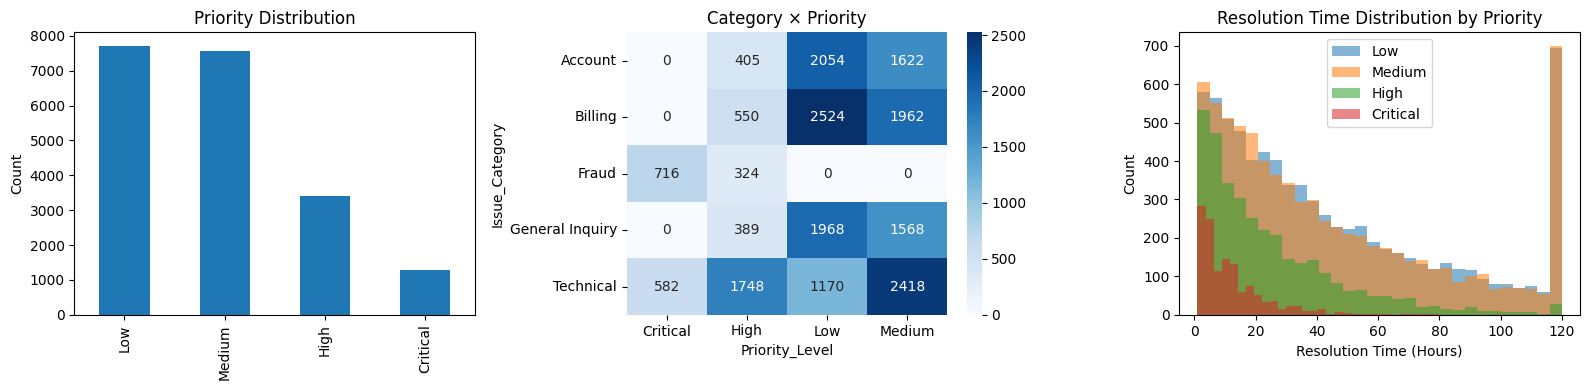

In [5]:
# EDA Graphs from saved stage-1 outputs
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df[PRIO_COL].value_counts().reindex(['Low', 'Medium', 'High', 'Critical']).plot(
    kind='bar', ax=axes[0]
)
axes[0].set_title('Priority Distribution')
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')

ct = pd.crosstab(df[CAT_COL], df[PRIO_COL])
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Category × Priority')

for p in ['Low', 'Medium', 'High', 'Critical']:
    vals = df.loc[df[PRIO_COL] == p, RT_COL].dropna()
    axes[2].hist(vals, bins=30, alpha=0.55, label=p)
axes[2].set_title('Resolution Time Distribution by Priority')
axes[2].set_xlabel('Resolution Time (Hours)')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.tight_layout()
plt.show()

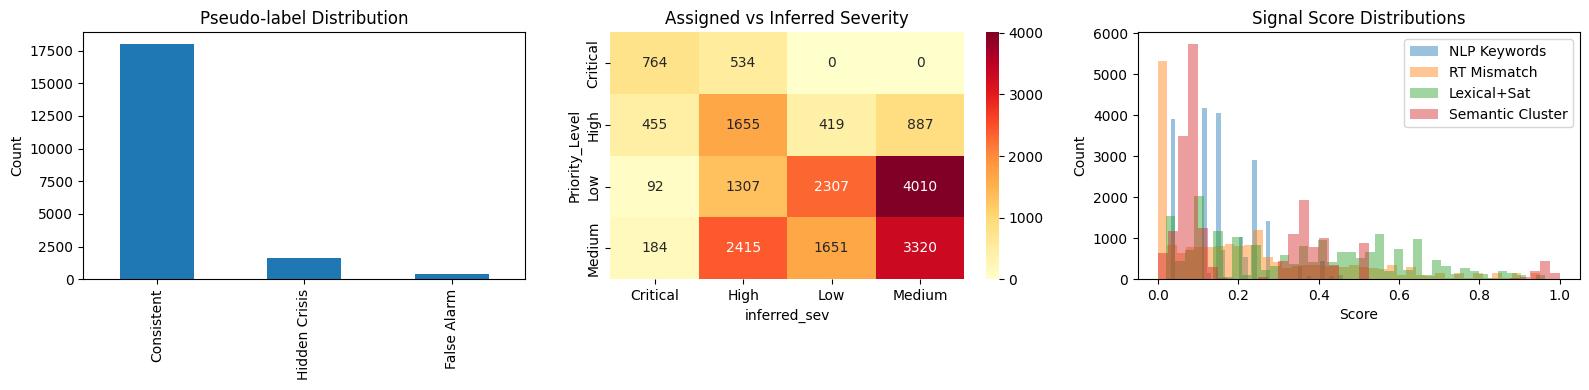

In [6]:
# Pseudo-label Analysis from stage-1 outputs
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df['mtype'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Pseudo-label Distribution')
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')

sns.heatmap(pd.crosstab(df[PRIO_COL], df['inferred_sev']),
            annot=True, fmt='d', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Assigned vs Inferred Severity')

for sig in SIGS:
    if sig in df.columns:
        axes[2].hist(df[sig], bins=40, alpha=0.45, label=NAMES[sig])
axes[2].set_title('Signal Score Distributions')
axes[2].set_xlabel('Score')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.tight_layout()
plt.show()

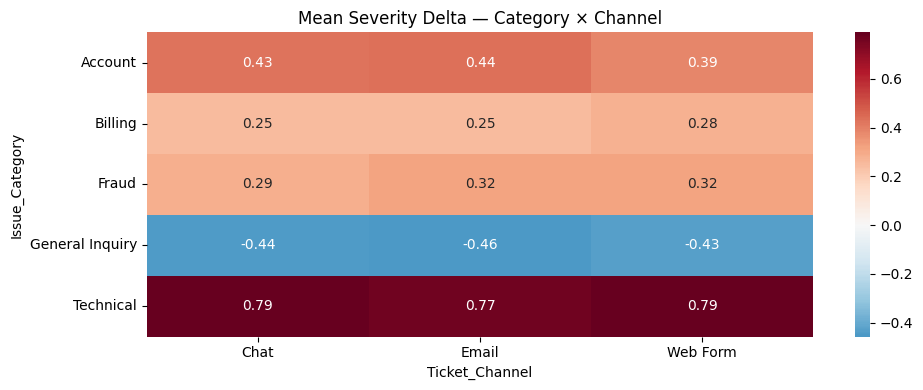

In [7]:
# Mean severity delta heatmap (saved outputs only)
pivot = df.pivot_table(values='delta', index=CAT_COL, columns=CH_COL, aggfunc='mean').fillna(0)

plt.figure(figsize=(10, 4))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Mean Severity Delta — Category × Channel')
plt.tight_layout()
plt.show()

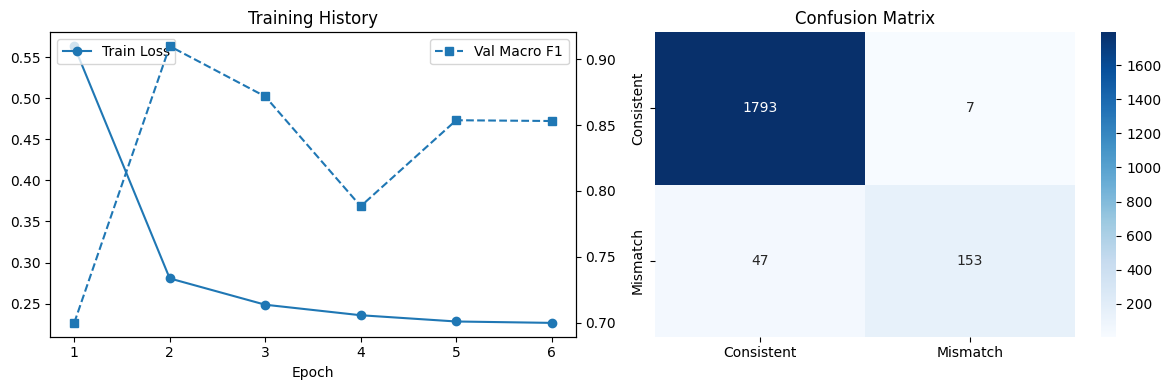

In [8]:
# Training history + confusion matrix from metrics.json
if EPOCHS == 0:
    raise ValueError("No training history found in outputs/metrics.json")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, EPOCHS + 1), hist['loss'], 'o-', label='Train Loss')
ax2 = axes[0].twinx()
ax2.plot(range(1, EPOCHS + 1), hist['val_f1'], 's--', label='Val Macro F1')

axes[0].set_title('Training History')
axes[0].set_xlabel('Epoch')
axes[0].legend(loc='upper left')
ax2.legend(loc='upper right')

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Consistent', 'Mismatch'],
    yticklabels=['Consistent', 'Mismatch'],
    ax=axes[1],
)
axes[1].set_title('Confusion Matrix')

plt.tight_layout()
plt.show()

In [10]:
import argparse, json, re, sys
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from peft import PeftModel

PMAP  = {'Low':0,'Medium':1,'High':2,'Critical':3}
RPMAP = {v:k for k,v in PMAP.items()}
BASE  = "microsoft/deberta-v3-small"

REQUIRED = ['Ticket_ID','Ticket_Subject','Ticket_Description','Issue_Category',
            'Priority_Level','Ticket_Channel','Resolution_Time_Hours','Satisfaction_Score']

ESCA_EV = [
    (r'\bfraud\w*\b',               'fraud_indicator',    0.35),
    (r'\bphish\w*\b',               'security_threat',    0.35),
    (r'\bhack\w*\b',                'security_threat',    0.30),
    (r'\bstolen\b',                 'security_threat',    0.30),
    (r'\bunauthori[sz]ed\b',        'security_threat',    0.28),
    (r'\bdata\s+breach\b',          'data_risk',          0.32),
    (r'\bdata\s+loss\b',            'data_risk',          0.30),
    (r'\bcrash\w*\b',               'system_failure',     0.22),
    (r'\bnot\s+(loading|working|responding)\b', 'functional_failure', 0.20),
    (r'\blocke?d\s+out\b',          'access_blocked',     0.24),
    (r'\bpayment\s+fail\w*\b',      'payment_failure',    0.22),
    (r'\bcompromised\b',            'account_risk',       0.28),
    (r'\bimmediately\b',            'urgency',            0.14),
    (r'\burgent\b',                 'urgency',            0.14),
    (r'\bransomware\b',             'security_threat',    0.40),
    (r'\bmalware\b',                'security_threat',    0.38),
]
DEESC_EV = [
    (r'\bhow\s+do\s+i\b',     'informational', -0.14),
    (r'\bwhere\s+is\b',       'informational', -0.14),
    (r'\bfeature\s+request\b','feature_req',   -0.16),
    (r'\bheadquarters\b',     'general_query', -0.20),
    (r'\broadmap\b',          'general_query', -0.16),
]
RT_BENCH = {
    ('Fraud','Critical'):4,    ('Fraud','High'):12,    ('Fraud','Medium'):28,
    ('Technical','Critical'):5,('Technical','High'):18,('Technical','Medium'):38, ('Technical','Low'):50,
    ('Billing','Critical'):6,  ('Billing','High'):20,  ('Billing','Medium'):42,   ('Billing','Low'):52,
    ('Account','High'):22,     ('Account','Medium'):40,('Account','Low'):50,
    ('General Inquiry','Medium'):35, ('General Inquiry','Low'):45,
}
CAT_SEV = {
    'Fraud':          {'exp':'Critical','w':0.28,'note':'Fraud carries inherent security risk'},
    'Technical':      {'exp':'High',    'w':0.18,'note':'Technical failures impact availability'},
    'Account':        {'exp':'Medium',  'w':0.12,'note':'Account issues affect user access'},
    'Billing':        {'exp':'Medium',  'w':0.10,'note':'Billing issues have financial impact'},
    'General Inquiry':{'exp':'Low',     'w':-0.15,'note':'General inquiries are informational'},
}

def rt_tier(h):
    if h<=10: return 'FAST'
    if h<=45: return 'MID'
    return 'SLOW'

def make_input(row):
    rt = float(row.get('Resolution_Time_Hours', 30))
    return (f"[SUBJ] {row['Ticket_Subject']} "
            f"[BODY] {row['Ticket_Description']} "
            f"| cat:{row['Issue_Category']} "
            f"| ch:{row['Ticket_Channel']} "
            f"| rt:{rt_tier(rt)} "
            f"| pri:{row['Priority_Level']}")

def load_model(mdl_dir, device):
    best = mdl_dir/'best'
    if not best.exists():
        sys.exit(f"No model at {best}. Run train_pipeline.py first.")
    tok   = AutoTokenizer.from_pretrained(str(best))
    base  = AutoModelForSequenceClassification.from_pretrained(BASE, num_labels=2, ignore_mismatched_sizes=True)
    model = PeftModel.from_pretrained(base, str(best)).float().to(device)
    model.eval()
    tf = mdl_dir/'threshold.npy'
    thr = float(np.load(str(tf))[0]) if tf.exists() else 0.5
    return tok, model, thr

def infer_batch(texts, tok, model, device, bs=64):
    probs = []
    for i in range(0, len(texts), bs):
        enc = tok(texts[i:i+bs], truncation=True, padding='max_length',
                  max_length=256, return_tensors='pt')
        enc = {k:v.to(device) for k,v in enc.items()}
        with torch.no_grad():
            out = model(**enc)
        probs += torch.softmax(out.logits.float(), -1)[:,1].cpu().tolist()
    return np.array(probs)

def dir_score(row):
    t   = f"{row['Ticket_Subject']} {row['Ticket_Description']}".lower()
    s   = sum(w for _,_,w in ESCA_EV+DEESC_EV if re.search(_,t))
    cat = row['Issue_Category']; pri = row['Priority_Level']
    cs  = CAT_SEV.get(cat, {'exp':'Medium','w':0.05})
    if PMAP.get(cs['exp'],1) > PMAP.get(pri,1): s += abs(cs['w'])
    elif PMAP.get(cs['exp'],1) < PMAP.get(pri,1): s -= abs(cs['w'])
    sat = int(row['Satisfaction_Score'])
    if sat<=2 and pri in ('Low','Medium'): s+=0.18
    elif sat>=4 and pri in ('Critical','High'): s-=0.12
    rt  = float(row['Resolution_Time_Hours'])
    exp = RT_BENCH.get((cat,pri), 40.0)
    r   = rt/max(exp,1)
    if r<0.4: s+=0.14
    elif r>2.5: s+=0.10
    return s

def get_verdict(row, prob):
    base = PMAP.get(row['Priority_Level'],1)
    d    = dir_score(row)
    if d < 0:
        bump     = 2 if prob>=0.90 else 1
        mtype    = 'False Alarm'
        inf_ord  = max(0, base-bump)
    else:
        bump     = 2 if prob>=0.85 else 1
        mtype    = 'Hidden Crisis'
        inf_ord  = min(3, base+bump)
    return RPMAP[inf_ord], mtype

def ev_text(row, mtype):
    t  = f"{row['Ticket_Subject']} {row['Ticket_Description']}".lower()
    ev = []
    for pat, etype, w in ESCA_EV+DEESC_EV:
        m = re.search(pat, t)
        if m:
            fld = 'Ticket_Subject' if re.search(pat, row['Ticket_Subject'].lower()) else 'Ticket_Description'
            ev.append({'signal':'keyword','type':etype,'value':m.group(0),'source_field':fld,'weight':round(w,3)})
    ev = [e for e in ev if (e['weight']>0) == (mtype=='Hidden Crisis')]
    return ev

def ev_rt(row, mtype):
    rt   = float(row['Resolution_Time_Hours'])
    cat  = row['Issue_Category']; pri = row['Priority_Level']
    exp  = RT_BENCH.get((cat,pri), 40.0)
    r    = rt/max(exp,1)
    if r<0.4:
        interp = f"Resolved in {rt:.0f}h vs ~{exp:.0f}h expected — {r:.1f}x faster, {'consistent with over-triage' if mtype=='False Alarm' else 'suggests true urgency exceeded the label'}"
        w = 0.25
    elif r>2.5:
        interp = f"Resolved in {rt:.0f}h vs ~{exp:.0f}h expected — {r:.1f}x slower, suggesting under-resourcing"
        w = 0.20
    else:
        interp = f"Resolved in {rt:.0f}h — within normal range for {pri} {cat} (~{exp:.0f}h)"
        w = 0.05
    return {'signal':'resolution_time','value':f"{rt:.0f}h",'expected':f"~{exp:.0f}h",
            'rt_ratio':round(r,2),'source_field':'Resolution_Time_Hours','interpretation':interp,'weight':round(w,3)}

def ev_sat(row, mtype):
    sat = int(row['Satisfaction_Score']); pri = row['Priority_Level']
    if mtype=='Hidden Crisis' and sat<=2 and pri in ('Low','Medium'):
        interp = f"Sat {sat}/5 on {pri} ticket — low satisfaction signals severity beyond assigned level"
        w = 0.18
    elif mtype=='False Alarm' and sat>=4 and pri in ('Critical','High'):
        interp = f"Sat {sat}/5 on {pri} ticket — high satisfaction consistent with over-triage"
        w = 0.12
    else:
        interp = f"Sat {sat}/5 — insufficient signal for {mtype} independently"
        w = 0.02
    return {'signal':'satisfaction_score','value':str(sat),'source_field':'Satisfaction_Score',
            'interpretation':interp,'weight':round(w,3)}

def ev_cat(row, mtype):
    cat = row['Issue_Category']; pri = row['Priority_Level']
    cs  = CAT_SEV.get(cat, {'exp':'Medium','w':0.05,'note':'Standard category'})
    eo  = PMAP.get(cs['exp'],1); po = PMAP.get(pri,1)
    if mtype=='Hidden Crisis' and eo>po:
        interp = f"{cat} warrants {cs['exp']} priority — {pri} is below baseline. {cs['note']}."
        w = abs(cs['w'])
    elif mtype=='False Alarm' and eo<po:
        interp = f"{cat} warrants {cs['exp']} priority — {pri} exceeds baseline. {cs['note']}."
        w = -abs(cs['w'])
    else:
        interp = f"{cat} assigned {pri} — within expected range."
        w = 0.03
    return {'signal':'category_baseline','value':cat,'expected_level':cs['exp'],
            'source_field':'Issue_Category','interpretation':interp,'weight':round(w,3)}

def delta_str(assigned, inferred):
    a = PMAP.get(assigned,1); i = PMAP.get(inferred,1); d = i-a
    if d>0:  return f"+{d} (under-prioritised by {d} level{'s' if d>1 else ''})"
    if d<0:  return f"{d} (over-prioritised by {abs(d)} level{'s' if abs(d)>1 else ''})"
    return "0 (borderline — signal conflict at same ordinal)"

def build_constraint(row, inferred, mtype, ev):
    cat = row['Issue_Category']; ch = row['Ticket_Channel']; pri = row['Priority_Level']
    rt  = float(row['Resolution_Time_Hours']); sat = int(row['Satisfaction_Score'])
    kp  = [e for e in ev if e['signal']=='keyword' and e.get('weight',0)>0]
    kn  = [e for e in ev if e['signal']=='keyword' and e.get('weight',0)<0]
    s1  = (f"This {cat} ticket submitted via {ch} was assigned {pri} priority, "
           f"but the model infers {inferred} severity from its content and metadata.")
    if mtype=='Hidden Crisis' and kp:
        s2 = f"Escalation indicators ({', '.join(repr(e['value']) for e in kp[:2])}) signal urgency beyond the assigned label."
    elif mtype=='False Alarm' and kn:
        s2 = f"Low-severity indicators ({', '.join(repr(e['value']) for e in kn[:2])}) suggest the ticket does not warrant {pri}."
    else:
        s2 = "Semantic patterns and metadata jointly signal a priority mismatch."
    s3 = (f"Resolution in {rt:.0f}h with satisfaction {sat}/5 "
          + ("supports under-prioritisation — earlier escalation would have reduced customer impact."
             if mtype=='Hidden Crisis'
             else f"suggests the issue was less severe than {pri} implies — resources may have been over-allocated."))
    return f"{s1} {s2} {s3}"

def build_dossier(row, prob):
    inferred, mtype = get_verdict(row, prob)
    kev  = ev_text(row, mtype)
    rtev = ev_rt(row, mtype)
    sev  = ev_sat(row, mtype)
    cev  = ev_cat(row, mtype)
    alev = sorted(kev+[rtev,sev,cev], key=lambda x:abs(x.get('weight',0)), reverse=True)
    return {
        'ticket_id':          str(row['Ticket_ID']),
        'assigned_priority':  row['Priority_Level'],
        'inferred_severity':  inferred,
        'mismatch_type':      mtype,
        'severity_delta':     delta_str(row['Priority_Level'], inferred),
        'confidence':         round(float(prob),4),
        'feature_evidence':   alev,
        'constraint_analysis':build_constraint(row, inferred, mtype, alev),
    }

def main():
    p = argparse.ArgumentParser()
    p.add_argument('--input',      required=True)
    p.add_argument('--output',     default='outputs')
    p.add_argument('--model-dir',  default='models/sia_model')
    p.add_argument('--threshold',  type=float, default=None)
    p.add_argument('--batch-size', type=int,   default=64)
    args = p.parse_args()

    out = Path(args.output); out.mkdir(parents=True, exist_ok=True)
    mdl = Path(args.model_dir)
    if not Path(args.input).exists(): sys.exit(f"ERROR: {args.input} not found")

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Device: {device}")

    df = pd.read_csv(args.input)
    miss = [c for c in REQUIRED if c not in df.columns]
    if miss: sys.exit(f"Missing columns: {miss}")
    for c in ['Ticket_Subject','Ticket_Description','Issue_Category','Ticket_Channel','Priority_Level']:
        df[c] = df[c].astype(str)
    print(f"Loaded {len(df):,} tickets")

    tok, model, saved_thr = load_model(mdl, device)
    thr = args.threshold if args.threshold is not None else saved_thr
    print(f"Threshold: {thr:.2f}")

    texts             = df.apply(make_input, axis=1).tolist()
    probs             = infer_batch(texts, tok, model, device, args.batch_size)
    df['prob']        = probs
    df['predicted']   = (probs>=thr).astype(int)
    df['verdict']     = df['predicted'].map({0:'Consistent',1:'Mismatch'})

    n = df['predicted'].sum()
    print(f"Flagged: {n:,}/{len(df):,} ({n/len(df)*100:.1f}%)")

    df[['Ticket_ID','Priority_Level','Issue_Category','prob','predicted','verdict']].to_csv(
        out/'predictions.csv', index=False)
    print(f"Saved: {out/'predictions.csv'}")

    flagged  = df[df['predicted']==1]
    dossiers = [build_dossier(r, r['prob']) for _,r in flagged.iterrows()]
    with open(out/'evidence_dossiers.json','w') as f:
        json.dump(dossiers, f, indent=2)
    print(f"Saved: {len(dossiers):,} dossiers → {out/'evidence_dossiers.json'}")

    hc = sum(1 for d in dossiers if d['mismatch_type']=='Hidden Crisis')
    fa = sum(1 for d in dossiers if d['mismatch_type']=='False Alarm')
    print(f"HC={hc:,}  FA={fa:,}")
    print("✓ Done")

def main():
    p = argparse.ArgumentParser()

    p.add_argument('--input',       default='/content/customer_support_tickets.csv')
    p.add_argument('--output',      default='outputs')
    p.add_argument('--model-dir',   default='models/sia_model')
    p.add_argument('--threshold',   type=float, default=None)
    p.add_argument('--batch-size',  type=int,   default=64)

    # Colab mein bina error run karne ke liye args=[]
    args = p.parse_args(args=[])

    out = Path(args.output); out.mkdir(parents=True, exist_ok=True)
    mdl = Path(args.model_dir)
    if not Path(args.input).exists(): sys.exit(f"ERROR: {args.input} not found")

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Device: {device}")

    df = pd.read_csv(args.input)
    miss = [c for c in REQUIRED if c not in df.columns]
    if miss: sys.exit(f"Missing columns: {miss}")
    for c in ['Ticket_Subject','Ticket_Description','Issue_Category','Ticket_Channel','Priority_Level']:
        df[c] = df[c].astype(str)
    print(f"Loaded {len(df):,} tickets")

    tok, model, saved_thr = load_model(mdl, device)
    thr = args.threshold if args.threshold is not None else saved_thr
    print(f"Threshold: {thr:.2f}")

    texts             = df.apply(make_input, axis=1).tolist()
    probs             = infer_batch(texts, tok, model, device, args.batch_size)
    df['prob']        = probs
    df['predicted']   = (probs>=thr).astype(int)
    df['verdict']     = df['predicted'].map({0:'Consistent',1:'Mismatch'})

    n = df['predicted'].sum()
    print(f"Flagged: {n:,}/{len(df):,} ({n/len(df)*100:.1f}%)")

    df[['Ticket_ID','Priority_Level','Issue_Category','prob','predicted','verdict']].to_csv(
        out/'predictions.csv', index=False)
    print(f"Saved: {out/'predictions.csv'}")

    flagged  = df[df['predicted']==1]
    dossiers = [build_dossier(r, r['prob']) for _,r in flagged.iterrows()]
    with open(out/'evidence_dossiers.json','w') as f:
        json.dump(dossiers, f, indent=2)
    print(f"Saved: {len(dossiers):,} dossiers → {out/'evidence_dossiers.json'}")

    hc = sum(1 for d in dossiers if d['mismatch_type']=='Hidden Crisis')
    fa = sum(1 for d in dossiers if d['mismatch_type']=='False Alarm')
    print(f"HC={hc:,}  FA={fa:,}")
    print("✓ Done")

if __name__ == '__main__':
    main()


Device: cuda
Loaded 20,000 tickets


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
pooler.dense.bias                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.bias                         | MISSING    | 
classifie

Threshold: 0.63
Flagged: 1,620/20,000 (8.1%)
Saved: outputs/predictions.csv
Saved: 1,620 dossiers → outputs/evidence_dossiers.json
HC=1,231  FA=389
✓ Done
